# Web Scraping y clustering con DBScan

## El web scraping con _web scraper_

Para este ejercicio se decidió realizar web scraping a la página: https://pokemondb.net/pokedex/stats/gen1. De la cual se extrajo la tabla completa que muestra ahí, para eso se usó la extensión _web scraper_. Una visualización de los datos que se tomaron de la página web se puede ver en la imagen a continuación:

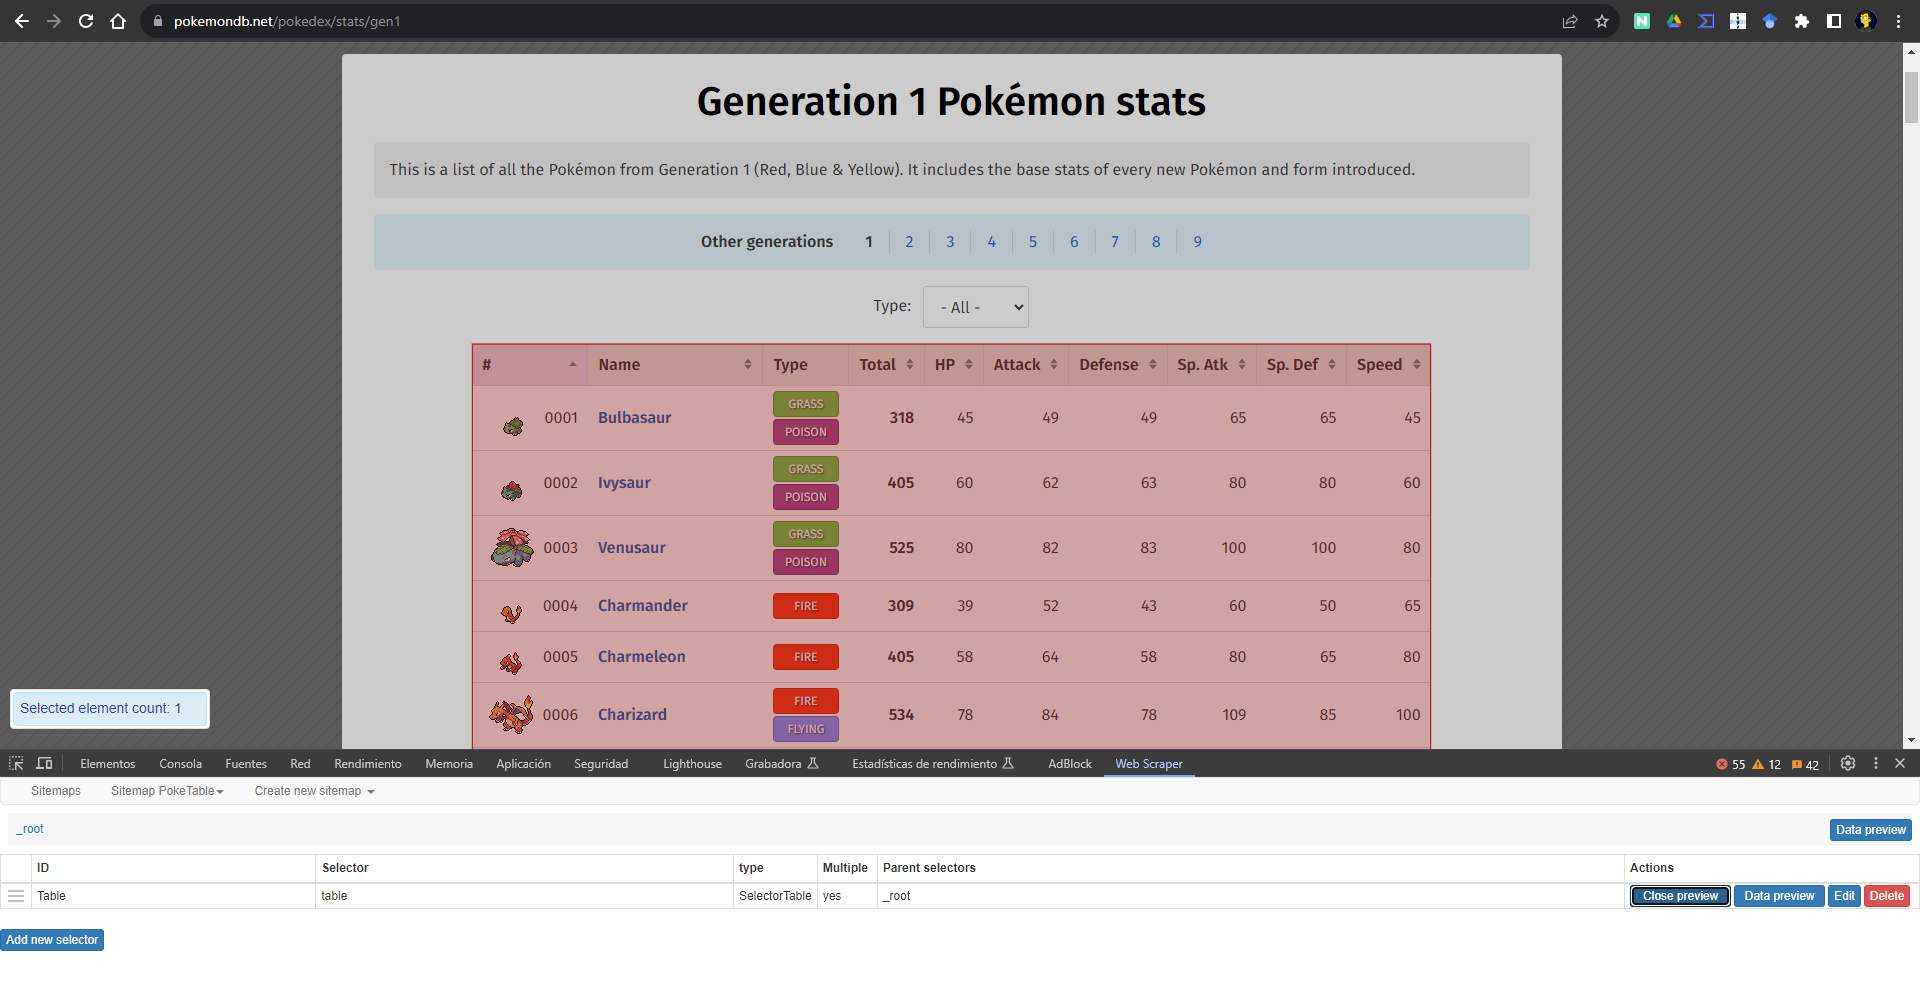

Las configuraciones del aplicativo para hacer web scraping se puede ver a continuación:

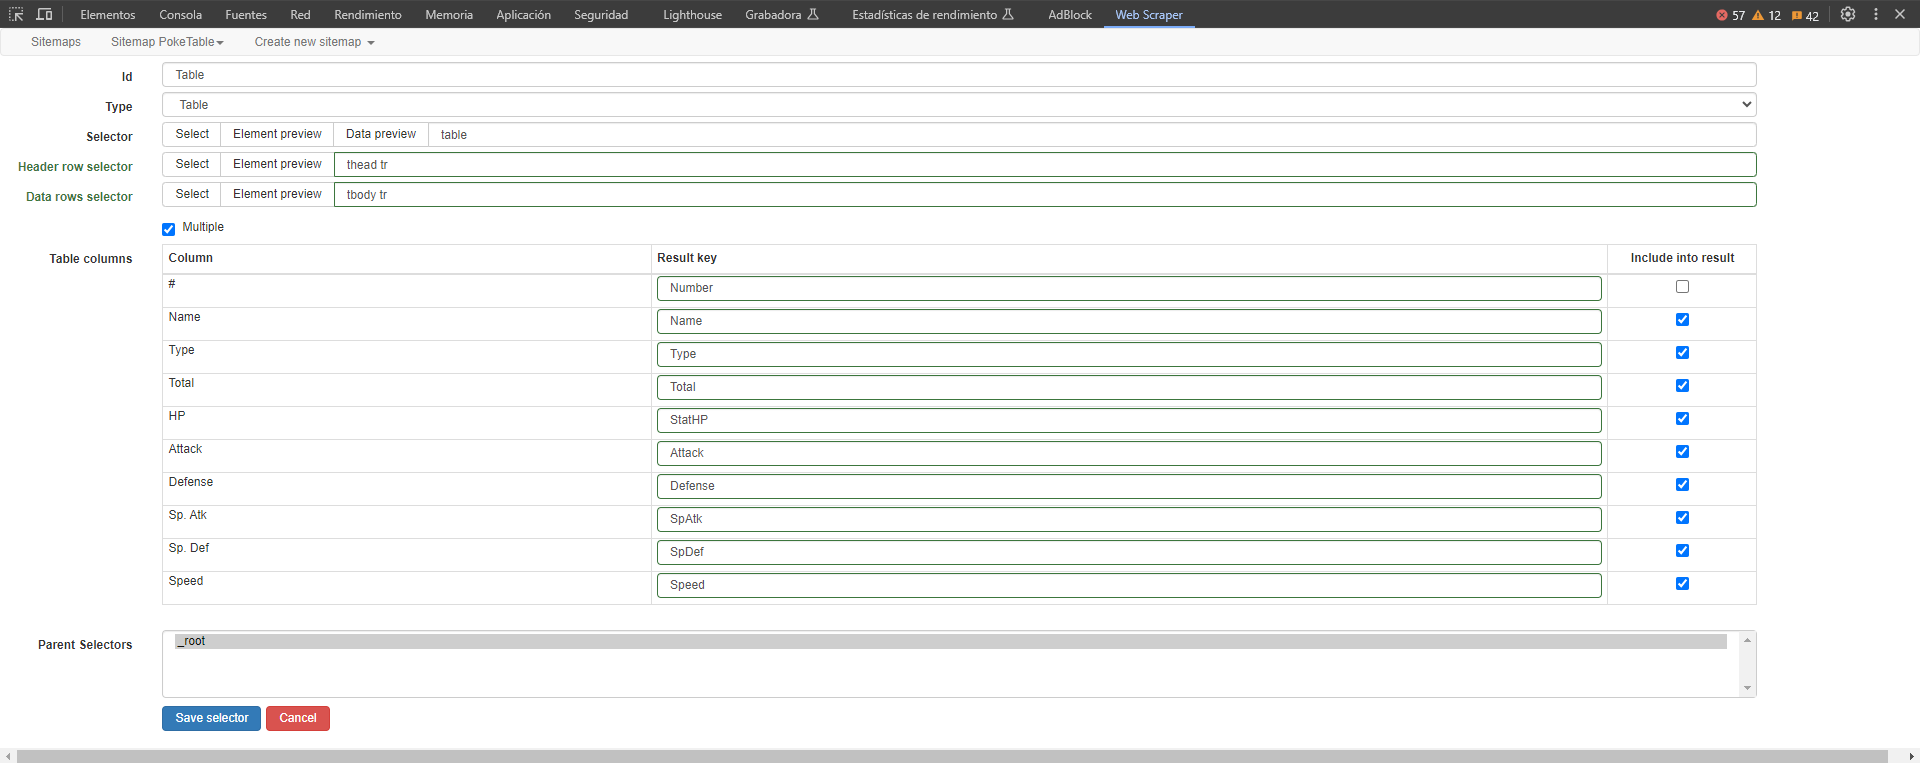

Junto a ello, los datos obtenidos tras haber realizado el web scraping se pueden ver en la siguiente imagen:

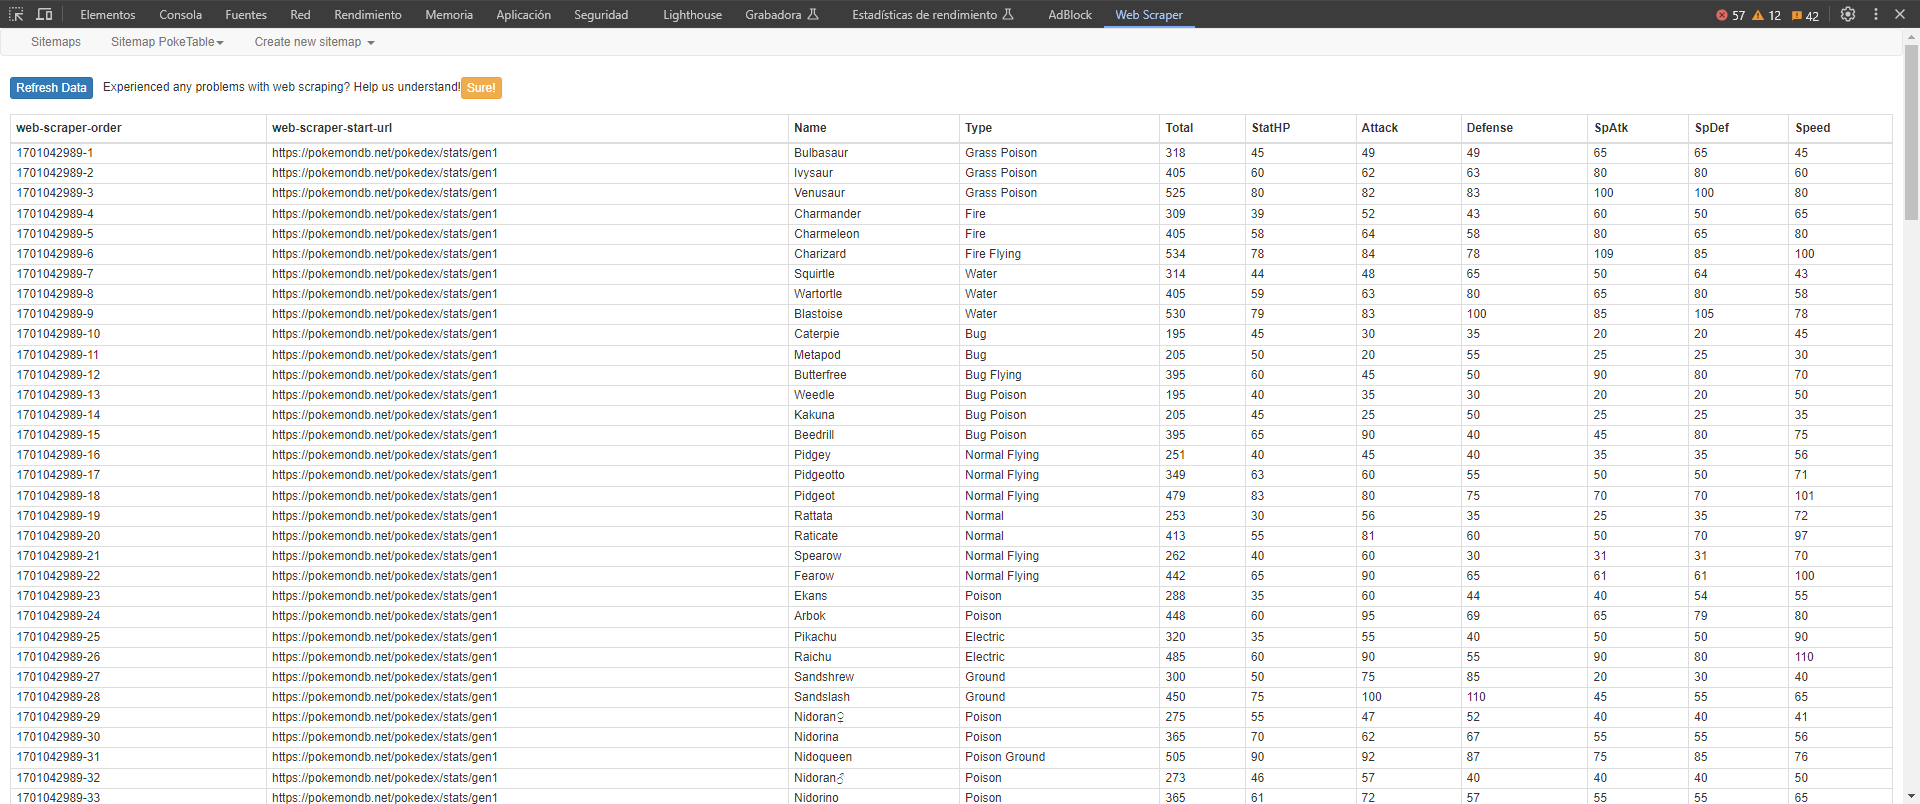

De estos datos obtenidos se obtiene el dataset a utilizar tras exportarlo como un archivo `.csv`, sin embargo, a estos datos primero es necesario arreglarlos un poco para dar un correcto manejo de los mismos.

## Importación y manejo de los datos para clustering

Primero se importa la librería `pandas` con el alias `pd`, luego se importa el dataset obtenido tras realizar web scraping que ya se mostró previamente.

De esto hay que hacer la claridad que en la importación del dataset se eliminaron las columnas "web-scraper-order" y "web-scraper-start-url" ya que no son de nuestro interés particular.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("PokeTable.csv").drop(["web-scraper-order", "web-scraper-start-url"], axis=1)
df

,Name,Type,Total,StatHP,Attack,Defense,SpAtk,SpDef,Speed
0,Bulbasaur,Grass\n Poison,318,45,49,49,65,65,45
1,Ivysaur,Grass\n Poison,405,60,62,63,80,80,60
2,Venusaur,Grass\n Poison,525,80,82,83,100,100,80
3,Charmander,Fire,309,39,52,43,60,50,65
4,Charmeleon,Fire,405,58,64,58,80,65,80
...,...,...,...,...,...,...,...,...,...
146,Dratini,Dragon,300,41,64,45,50,50,50
147,Dragonair,Dragon,420,61,84,65,70,70,70
148,Dragonite,Dragon\n Flying,600,91,134,95,100,100,80
149,Mewtwo,Psychic,680,106,110,90,154,90,130


Con esto realizado, se organiza la columna llamada "Type" la cual posee los tipos de los Pokémon, los tipos de los Pokémon pueden variar entre uno y dos tipos, donde dos es el máximo de tipos que se puede tener, así en primera instancia se ubica el primer tipo de los Pokémon en la columna "Type1" que para aquellos Pokémon que tienen un único tipo, se ubicará su tipo ahí. 

Para esto nos ayudamos del método `.apply()` y  `.strip()` donde la primera divide el texto en dos usando el delimitador `\n` de la cual toma el primer texto obtenido (el primer tipo) y la segunda elimina cualquier espacio que exista, así solamente se está tomando el texto inicial.

Luego, se realiza algo muy similar a lo explicado previamente con los métodos usados solo que esta vez se toma el segundo texto (el segundo tipo) y se coloca una condición dentro del método partiendo del delimitador `\n`, si este existe realiza el proceso que se ha venido mencionando y si este no existe, llena ese espacio con `None` indicando que no tiene segundo tipo.

In [3]:
# Eliminar el texto posterior a \n de la columna original 'Type'
df['Type1'] = df['Type'].apply(lambda x: x.split('\n', 1)[0].strip())

# Eliminar el texto anterior a \n de la columna original 'Type'
df['Type2'] = df['Type'].apply(lambda x: x.split('\n', 1)[1].strip() if '\n' in x else None)

# Elimina la columna 'Type' y actualiza con las nuevas columnas
df.drop("Type",axis=1)
df = df[['Name','Type1','Type2','StatHP','Attack','Defense','SpAtk','SpDef','Speed','Total']]

Ahora, podemos ver como va el DataFrame tras todas las modificaciones mencionadas:

In [4]:
df

,Name,Type1,Type2,StatHP,Attack,Defense,SpAtk,SpDef,Speed,Total
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,318
1,Ivysaur,Grass,Poison,60,62,63,80,80,60,405
2,Venusaur,Grass,Poison,80,82,83,100,100,80,525
3,Charmander,Fire,None,39,52,43,60,50,65,309
4,Charmeleon,Fire,None,58,64,58,80,65,80,405
...,...,...,...,...,...,...,...,...,...,...
146,Dratini,Dragon,None,41,64,45,50,50,50,300
147,Dragonair,Dragon,None,61,84,65,70,70,70,420
148,Dragonite,Dragon,Flying,91,134,95,100,100,80,600
149,Mewtwo,Psychic,None,106,110,90,154,90,130,680


Para tomar los datos que se usarán al hacer clustering se insta un nuevo DataFrame llamado `X` el cual contendrá todos las estadísticas de los Pokémon sin tener en cuenta su tipo o nombre, esto porque son datos categóricos. Entonces, ¿por qué se realizó el trabajo anterior con los tipos?, esto se hizo ya que por ser datos categóricos no necesariamente deben ser datos que se deban omitir a la hora de hacer clustering, se pueden cambiar por datos numéricos basados en una convención propia y usarlos en los clusters, sin embargo, este no es el caso.

In [5]:
X = df.drop(["Name","Type1","Type2"],axis=1)
X

,StatHP,Attack,Defense,SpAtk,SpDef,Speed,Total
0,45,49,49,65,65,45,318
1,60,62,63,80,80,60,405
2,80,82,83,100,100,80,525
3,39,52,43,60,50,65,309
4,58,64,58,80,65,80,405
...,...,...,...,...,...,...,...
146,41,64,45,50,50,50,300
147,61,84,65,70,70,70,420
148,91,134,95,100,100,80,600
149,106,110,90,154,90,130,680


Para obtener una mejor visualización de los datos se usa el método `.info()` así se tiene la garantía que se están manejando datos correctos para el clusters, en este caso, datos tipo entero.

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   StatHP   151 non-null    int64
 1   Attack   151 non-null    int64
 2   Defense  151 non-null    int64
 3   SpAtk    151 non-null    int64
 4   SpDef    151 non-null    int64
 5   Speed    151 non-null    int64
 6   Total    151 non-null    int64
dtypes: int64(7)
memory usage: 8.4 KB


## Aplicación de clustering con DBScan

Primero se importan todas las librerías necesarias para realizar clustering, se puede ver un poco de su función en los comentarios adjuntos a las mismas.

In [7]:
import numpy as np # Manejo de matemáticas
import matplotlib.pyplot as plt # Manejo de gráficas
from sklearn.cluster import DBSCAN # Algoritmo DBScan de sklearn
from sklearn.preprocessing import StandardScaler # Algoritmo de estandarización de datos
from sklearn.neighbors import NearestNeighbors # Algoritmo de detección de vecinos cercanos
from sklearn.metrics import silhouette_score # Métrica de evaluación

Primero se estandarizan todos los datos para un mejor manejo, el nuevo DataFrame estandarizado se guardará en `X_scaled`.

In [8]:
# Escalar los datos para que tengan media cero y varianza unitaria
X_scaled = StandardScaler().fit_transform(X)

Tras haber realizado esto, se usa el algoritmo `NearestNeighbors` para detectar los vecinos cercanos y el posible valor del parámetro `eps` usando el método de la rodilla, en este caso solamente se deja fijo el número de vecinos el cual puede variar y solamente nos ayudará en tener un rango de valores correcto para aplicar un algoritmo de optimización y encontrar los mejores parámetros.

Text(0, 0.5, 'k-ésima distancia al vecino más cercano')

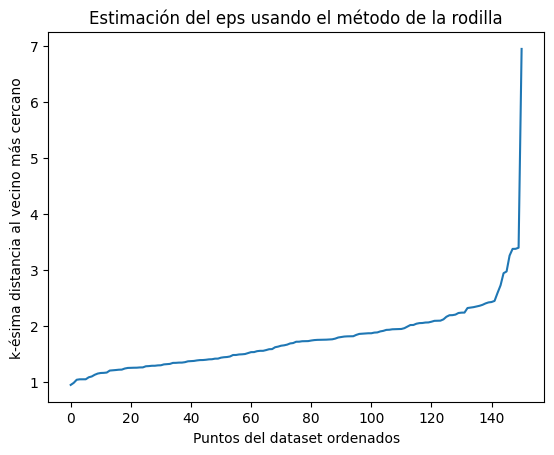

In [9]:
N = 10 # Propuesta, no necesariamente es el final
nbrs = NearestNeighbors(n_neighbors=N).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:,N-1]
plt.plot(distances)
plt.title('Estimación del eps usando el método de la rodilla')
plt.xlabel('Puntos del dataset ordenados')
plt.ylabel('k-ésima distancia al vecino más cercano')

Así, nos damos cuenta que el rango en el cual se puede manejar el parámetro `eps` es entre 0.8 (aproximadamente) y 7.0 (aproximadamente). Luego, con ayuda de la métrica `silhouette_score` se analiza cuál debe ser esos parámetros `eps` y `min_samples` que presentan una mejor métrica y con ello un mejor clustering.

In [10]:
# Inicia con valores nulos
best_eps = None
best_min_samples = None
best_num_clusters = 0
best_silhouette_score = -1

# Itera entre diferentes valores para eps y min_samples y encuentra el de la mejor métrica silhouette_score
for eps in np.arange(0.8, 7.0, 0.1):
    for min_samples in range(5, 20):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # Ignora clusters ruidosos (-1)
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if num_clusters > 1:  # Necesitas al menos dos clusters
            silhouette_avg = silhouette_score(X_scaled, labels)
            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_eps = eps
                best_min_samples = min_samples
                best_num_clusters = num_clusters

# Imprimir los mejores resultados
print("Mejores parámetros:")
print(f"Eps: {best_eps}")
print(f"Min_samples: {best_min_samples}")
print(f"Número de clusters: {best_num_clusters}")
print(f"Puntuación de silueta: {best_silhouette_score}")

Mejores parámetros:
Eps: 1.4
Min_samples: 16
Número de clusters: 2
Puntuación de silueta: 0.06592933079372384


Se guardan esos valores para `eps` y `min_samples` óptimos que arroja el algoritmo y se usan luego como tal en el algoritmo `DBSCAN()`, posterior a ello se imprimen una serie de gráficas de contraste entre las combinaciones de features posibles dentro de las columnas de `X_scaled` donde como es de esperarse, sobre la diagonal debe haber una correlación lineal entre las características.

Esto se hace para ver como fue el clustering para los diferentes datos y ver como esto impacta por combinación de features.

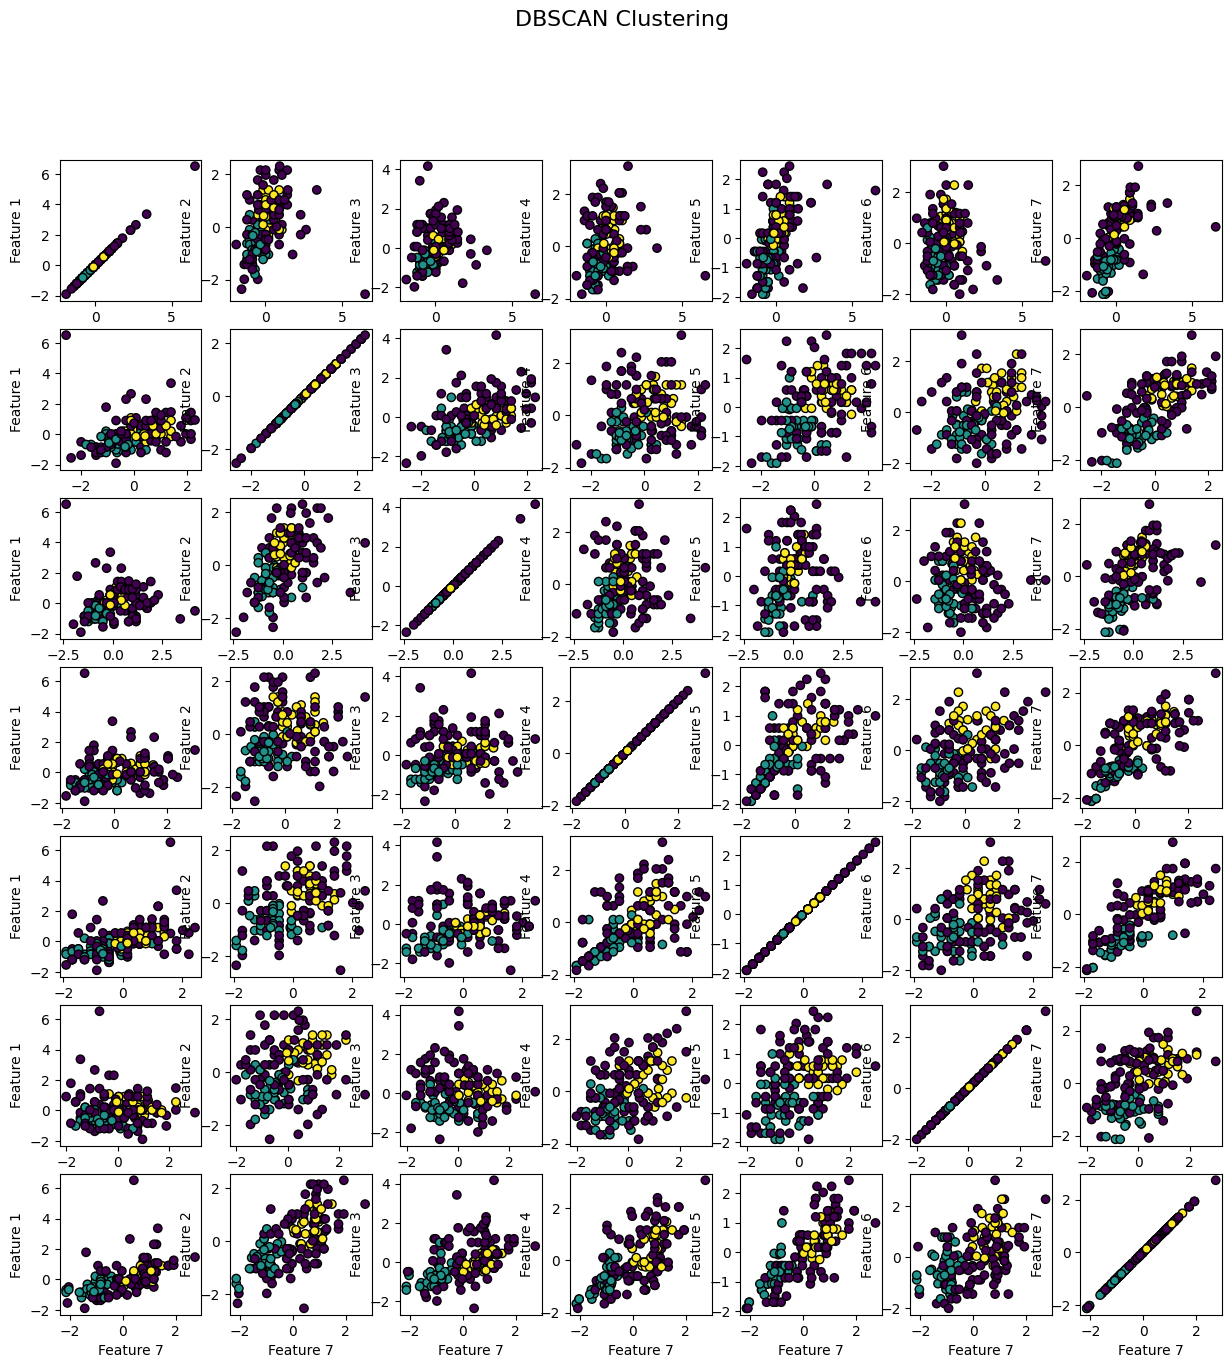

In [11]:
# Aplicar DBSCAN
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
y_pred = dbscan.fit_predict(X_scaled)
df['Clusters'] = y_pred # Agregar los resultados al dataset original

# Visualizar los resultados en gráficos de dispersión para todas las combinaciones de características
num_features = X_scaled.shape[1]

fig, axes = plt.subplots(num_features, num_features, figsize=(15, 15))

for i in range(num_features):
    for j in range(num_features):
        axes[i, j].scatter(X_scaled[:, i], X_scaled[:, j], c=y_pred, cmap='viridis', edgecolors='k')
        axes[i, j].set_xlabel(f'Feature {i+1}')
        axes[i, j].set_ylabel(f'Feature {j+1}')

fig.suptitle('DBSCAN Clustering', fontsize=16)
plt.show()

Finalmente, se crea una figura 3D usando las dos primeras features para ver qué tal fue el clustering, esto es meramente ilustrativo por lo que se pueden cambiar las features y ver qué tal se ve para todas las combinaciones existentes. Algo similar a la gráfica anterior solo que en 3D. Junto a ello, una visualización dentro del dataset del clustering realizado.

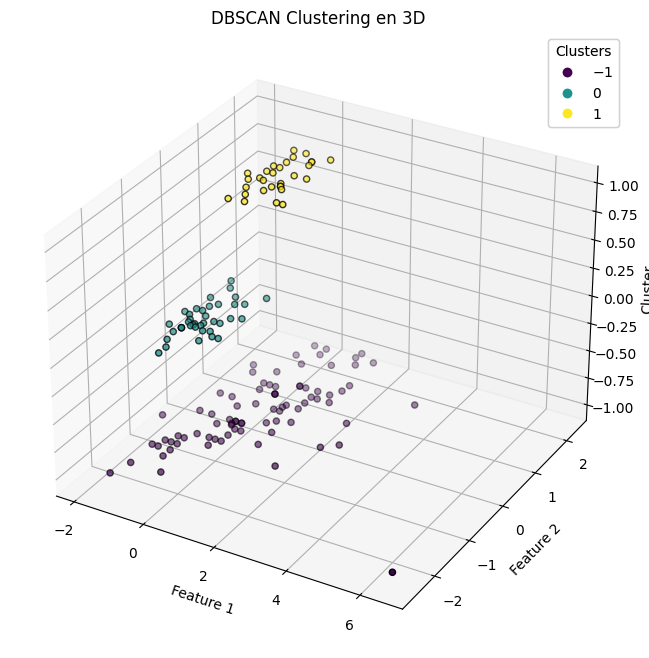

In [12]:
# Crear una figura 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Visualizar los resultados en un diagrama 3D
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], y_pred, c=y_pred, cmap='viridis', edgecolors='k')

# Etiquetas de los ejes
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Cluster')

# Añadir barra de colores
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

plt.title('DBSCAN Clustering en 3D')
plt.show()

In [13]:
df

,Name,Type1,Type2,StatHP,Attack,Defense,SpAtk,SpDef,Speed,Total,Clusters
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,318,0
1,Ivysaur,Grass,Poison,60,62,63,80,80,60,405,-1
2,Venusaur,Grass,Poison,80,82,83,100,100,80,525,1
3,Charmander,Fire,None,39,52,43,60,50,65,309,0
4,Charmeleon,Fire,None,58,64,58,80,65,80,405,1
...,...,...,...,...,...,...,...,...,...,...,...
146,Dratini,Dragon,None,41,64,45,50,50,50,300,0
147,Dragonair,Dragon,None,61,84,65,70,70,70,420,1
148,Dragonite,Dragon,Flying,91,134,95,100,100,80,600,-1
149,Mewtwo,Psychic,None,106,110,90,154,90,130,680,-1


## Conclusiones

Del anterior trabajo se puede concluir que el algoritmo para clustering DBScan es bastante sensible a los parámetros `eps` y `min_samples` por lo que es pertinente usar métodos de métricas para encontrar esos parámetros óptimos en los cuales se pueden obtener los mejores clusters. Como algo adicional, los clusters generados a primera vista del dataset pueden ser correspondidos a las etapas de los Pokémon, es decir, en qué etapa evolutiva se encuentran, si es la etapa inicial, intermedia o final, sin embargo, como este no es un algoritmo de _clasificación_ llegar a una conclusión fuerte respecto a ello es complicado, es de notar que los grupos (clusters) se generaron muy bien.